In [1]:
import torch
import numpy as np
import scipy
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from tqdm import tqdm

import sklearn
import sklearn.datasets as datasets
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_classification

#### Simulate data

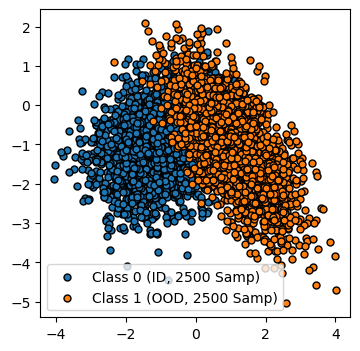

In [21]:
plt.figure(figsize=(4, 4))
X, Y = make_classification(
    n_samples=5000, n_features=2, n_redundant=0, n_informative=2, n_classes=2, n_clusters_per_class=1,
    weights=[0.5, 0.5], class_sep=1.1, random_state=30, shuffle=True, flip_y=0.0
)
text = ["ID", "OOD"]
for i in range(2):
    dat = X[Y == i]
    plt.scatter(dat[:,0], dat[:,1], label=f"Class {str(i)} ({text[i]}, {len(dat)} Samp)", marker="o", s=25, edgecolor="k")
plt.legend()
plt.show()

In [22]:
mask_in = (Y == 0) # Class 0 is in distribution (Class 1 is OOD)
nr_train = 500

X_in = X[mask_in]
Y_in = Y[mask_in]
X_out = X[~mask_in]
Y_out = Y[~mask_in]

X_in_train = X_in[:nr_train]
Y_in_train = Y_in[:nr_train]
X_out_train = X_out[:nr_train]
Y_out_train = Y_out[:nr_train]

X_in_test = X_in[nr_train:]
Y_in_test = Y_in[nr_train:]
X_out_test = X_out[nr_train:]
Y_out_test = Y_out[nr_train:]

print(
    "Train Data In: ", X_in_train.shape, Y_in_train.shape,
    "\nTrain Data Out: ", X_out_train.shape, Y_out_train.shape,
    "\nTest Data In: ", X_in_test.shape, Y_in_test.shape,
    "\nTest Data Out: ", X_out_test.shape, Y_out_test.shape
)

Train Data In:  (500, 2) (500,) 
Train Data Out:  (500, 2) (500,) 
Test Data In:  (2000, 2) (2000,) 
Test Data Out:  (2000, 2) (2000,)


In [23]:
X_train = np.concatenate([X_in_train, X_out_train], axis=0)
Y_train = np.concatenate([Y_in_train, Y_out_train], axis=0)
X_test = np.concatenate([X_in_test, X_out_test], axis=0)
Y_test = np.concatenate([Y_in_test, Y_out_test], axis=0)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((1000, 2), (1000,), (4000, 2), (4000,))

### Train binary classifier (auxiliary model)

In [24]:
clf = SVC(kernel="rbf", C=1.0)
clf.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = clf.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('Classification Report:')
print(classification_report(Y_test, Y_pred))

# False Positive Rate
fpr = np.sum((Y_pred == 1) & (Y_test == 0)) / np.sum(Y_test == 0) # (H1|H0) / H0
print(f'False Positive Rate: {fpr:.2f}')

Accuracy: 0.91
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2000
           1       0.88      0.95      0.91      2000

    accuracy                           0.91      4000
   macro avg       0.91      0.91      0.91      4000
weighted avg       0.91      0.91      0.91      4000

False Positive Rate: 0.13


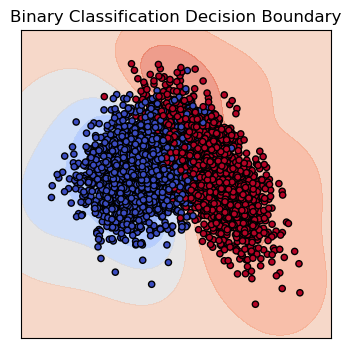

In [25]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(4, 4)

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method = "decision_function",
    cmap=plt.cm.coolwarm,
    alpha=0.7,
    ax=ax
)
ax.scatter(X[:,0], X[:,1], c=Y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
ax.set_xticks(())
ax.set_yticks(())
ax.set_title("Binary Classification Decision Boundary")

plt.show()


### Stream setting for testing

In [26]:
T = 2000 # nr of time steps
ood_prob = 0.5

# reference (calibration) samples
stream_x1 = np.zeros(shape=(T, 2))
stream_y1 = np.zeros(T)
# test samples
stream_x2 = np.zeros(shape=(T, 2))
stream_y2 = np.zeros(T)

# generate data stream
for t in range(0, T):
    
    # sample from reference (calibration) data
    i = np.random.randint(0, len(X_in_test))
    stream_x1[t] = X_in_test[i]
    stream_y1[t] = Y_in_test[i]
    
    # simulate test sample (in or out of distribution)
    bern = np.random.binomial(1, ood_prob)
    
    if bern == 0: # in distribution
        i = np.random.randint(0, len(X_in_test))
        stream_x2[t] = X_in_test[i]
        stream_y2[t] = Y_in_test[i]
    elif bern == 1: # out of distribution
        i = np.random.randint(0, len(X_out_test))
        stream_x2[t] = X_out_test[i]
        stream_y2[t] = Y_out_test[i]

In [27]:
# Example of a stream of data
for t in range(80, 100):
    print(f"Step {t} | Reference sample: (X,Y) = ({stream_x1[t]}, {stream_y1[t]}) | Test sample: (X,Y) = ({stream_x2[t]}, {stream_y2[t]})")

Step 80 | Reference sample: (X,Y) = ([-0.42820281 -0.92030056], 0.0) | Test sample: (X,Y) = ([ 2.35872276 -1.94274454], 1.0)
Step 81 | Reference sample: (X,Y) = ([-1.0870161 -0.1478465], 0.0) | Test sample: (X,Y) = ([ 0.48134142 -0.08605071], 1.0)
Step 82 | Reference sample: (X,Y) = ([-0.75868104 -1.04319902], 0.0) | Test sample: (X,Y) = ([-1.52520968 -0.60025644], 0.0)
Step 83 | Reference sample: (X,Y) = ([-1.62678095 -0.95065544], 0.0) | Test sample: (X,Y) = ([ 1.15055856 -1.12847975], 1.0)
Step 84 | Reference sample: (X,Y) = ([-1.79186162 -1.9221394 ], 0.0) | Test sample: (X,Y) = ([-1.10317973 -0.96511824], 0.0)
Step 85 | Reference sample: (X,Y) = ([-2.01199103 -0.42480186], 0.0) | Test sample: (X,Y) = ([-0.72527218 -0.13218782], 0.0)
Step 86 | Reference sample: (X,Y) = ([-2.01689775 -0.26769347], 0.0) | Test sample: (X,Y) = ([0.04490034 1.01761971], 1.0)
Step 87 | Reference sample: (X,Y) = ([-0.36134637 -1.3066715 ], 0.0) | Test sample: (X,Y) = ([ 2.00947506 -0.93101691], 1.0)
Step

### Evidence collectors

In [28]:
# ONS algorithm for betting strategy update
def lam_ons(v, lam, a): 
    z = v / (1 - v * lam)
    a = a + z**2
    lam = min(0.5, max(-0.5, lam - (2 / 2 - np.log(3)) * (z / a)))
    return lam, a

# Shekhar & Ramdas 2023 - two sample testing
def betting_twosamp(pred_x1, pred_x2, prev_eval, lam, a):
    v = (pred_x2 - pred_x1) # has to be in [-1, 1]
    assert v >= -1 and v <= 1
    
    lam, a = lam_ons(v, lam, a)
    evidence = prev_eval * (1 + lam * v)
    return evidence, lam, a

# Shekhar & Ramdas 2023 - one sample testing
def betting_onesamp(exp_h0, pred_x2, prev_eval, lam, a):
    v = (pred_x2 - exp_h0) # has to be in [-1, 1]
    assert v >= -1 and v <= 1
    
    lam, a = lam_ons(v, lam, a)
    evidence = prev_eval * (1 + lam * v)
    return evidence, lam, a


### Stream prediction and evidence collection

In [66]:
alpha = 0.1 # target fpr
stream_fpr = np.zeros(T)

stream_pred_x1 = np.zeros(T)
stream_pred_x2 = np.zeros(T)

stream_eval = np.ones(T)
stream_lam = np.zeros(T)
# evidence params init
lam = 0.0
a = 1.0

for t in tqdm(range(0, T), desc="Time steps"):
    
    pred_x1 = clf.predict(stream_x1[t].reshape(1, -1))[0] # reference pred
    pred_x2 = clf.predict(stream_x2[t].reshape(1, -1))[0] # test pred
    
    stream_pred_x1[t] = pred_x1
    stream_pred_x2[t] = pred_x2
    
    # stream_fpr[t] = np.nan_to_num(np.sum((stream_pred_x2[:t+1] == 1) & (stream_y2[:t+1] == 0)) / np.sum(stream_y2[:t+1] == 0), nan=0.0)
    stream_fpr[t] = np.nan_to_num(np.sum((stream_pred_x2[:t+1] == 1) & (stream_y2[:t+1] == 0)) / np.sum(stream_y2 == 0), nan=0.0)
    
    if (t > 0):
        
        # evidence, lam, a = betting_twosamp(pred_x1, pred_x2, stream_eval[t-1], lam, a)
        evidence, lam, a = betting_onesamp(ood_prob, pred_x2, stream_eval[t-1], lam, a)
        
        stream_eval[t] = evidence
        stream_lam[t] = lam

Time steps: 100%|██████████| 2000/2000 [00:00<00:00, 2181.43it/s]


In [67]:
t_candidate = np.where(stream_fpr >= alpha)[0]
if len(t_candidate) == 0:
    t_opt = T
else:
    t_opt = t_candidate.min()

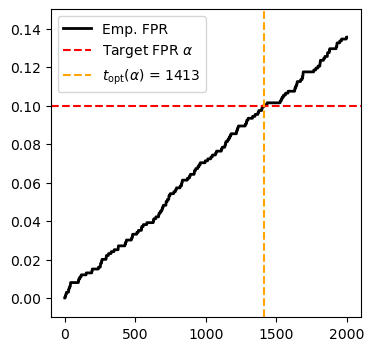

In [68]:
plt.figure(figsize=(4, 4))
plt.plot(stream_fpr, label="Emp. FPR", color="black", lw=2)
plt.axhline(y=alpha, color="red", linestyle="--", label=r"Target FPR $\alpha$")
plt.axvline(x=t_opt, color="orange", linestyle="--", label=r"$t_{\text{opt}}(\alpha)$ = " + str(t_opt))
plt.ylim(-0.01, 0.15)
# plt.xlim(1600, 1800)
plt.legend()
plt.show()

In [69]:
t_ev_candidate = np.where(stream_eval >= 1/alpha)[0]
if len(t_ev_candidate) == 0:
    t_ev = T
else:
    t_ev = t_ev_candidate.min()

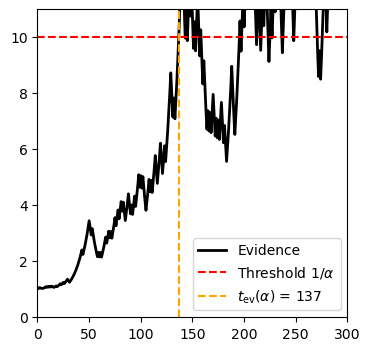

In [73]:
plt.figure(figsize=(4, 4))
plt.plot(stream_eval, label="Evidence", color="black", lw=2)
plt.axhline(y=1/alpha, color="red", linestyle="--", label=r"Threshold $1/\alpha$")
plt.axvline(x=t_ev, color="orange", linestyle="--", label=r"$t_{\text{ev}}(\alpha)$ = " + str(t_ev))
plt.ylim(-0.01, 1/alpha + 1)
plt.xlim(0, 300)
plt.legend()
plt.show()

In [71]:
for t in range(0, 200):
    print(f"Step {t} | (True Ref, True Test) = ({stream_y1[t]}, {stream_y2[t]}) | (Pred Ref, Pred Test) = ({stream_pred_x1[t]}, {stream_pred_x2[t]}) | Evidence = {stream_eval[t]}")

Step 0 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 0.0) | Evidence = 1.0
Step 1 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 0.0) | Evidence = 1.019722457733622
Step 2 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 0.0) | Evidence = 1.0568155756827557
Step 3 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 1.0) | Evidence = 1.0327968384800226
Step 4 | (True Ref, True Test) = (0.0, 1.0) | (Pred Ref, Pred Test) = (0.0, 1.0) | Evidence = 1.0218853666693535
Step 5 | (True Ref, True Test) = (0.0, 1.0) | (Pred Ref, Pred Test) = (0.0, 1.0) | Evidence = 1.0222846126229836
Step 6 | (True Ref, True Test) = (0.0, 1.0) | (Pred Ref, Pred Test) = (0.0, 1.0) | Evidence = 1.0328628795327972
Step 7 | (True Ref, True Test) = (0.0, 0.0) | (Pred Ref, Pred Test) = (0.0, 1.0) | Evidence = 1.052967797911766
Step 8 | (True Ref, True Test) = (0.0, 1.0) | (Pred Ref, Pred Test) = (1.0, 1.0) | Evidence = 1.0823117868080692


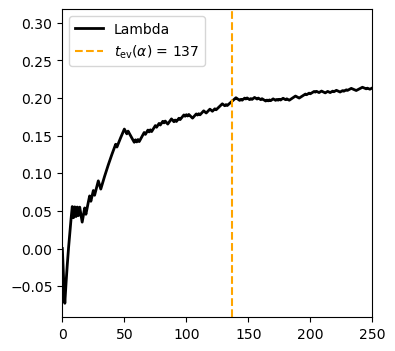

In [72]:
plt.figure(figsize=(4, 4))
plt.plot(stream_lam, label="Lambda", color="black", lw=2)
plt.axvline(x=t_ev, color="orange", linestyle="--", label=r"$t_{\text{ev}}(\alpha)$ = " + str(t_ev))
plt.xlim(0, 250)
plt.legend()
plt.show()